# Notebook 1: Data Cleaning and Exploratory Analysis
**Capstone Project — Diabetes Patient Readmission Prediction**  
**Author:** Jayson Gundayao  
**Dataset:** [Diabetes Hospital Readmission Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

This notebook covers:
1. Environment setup and data loading
2. Initial data inspection
3. Missing value analysis and treatment
4. Target variable analysis
5. Exploratory data analysis (EDA)
6. Key observations and takeaways


## 1. Environment Setup

In [54]:
# --- PERSONAL MISSION STATEMENT ---
# This project is dedicated to my family, many of whom have struggled with
# the complexities of diabetes. My goal is to use the skills learned in
# the UC Berkeley AI/ML program to develop predictive tools that can
# help families avoid the cycle of re-admission and provide better
# quality of life for diabetic patients.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 2. Data Loading

Download the a copy of dataset from Kaggle into the file `data/diabetic_data.csv` in the `data/` directory.

In [55]:
DATA_PATH = 'data/diabetic_data.csv'

df = pd.read_csv(DATA_PATH, na_values=['?', 'None', 'nan', ''])

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Dataset Shape: (143424, 26)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'primary_diagnosis_code', 'other_diagnosis_codes', 'number_outpatient', 'number_inpatient', 'number_emergency', 'num_lab_procedures', 'number_diagnoses', 'num_medications', 'num_procedures', 'ndc_code', 'max_glu_serum', 'A1Cresult', 'change', 'readmitted']


In [56]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,number_emergency,num_lab_procedures,number_diagnoses,num_medications,num_procedures,ndc_code,max_glu_serum,A1Cresult,change,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,0,41,1,1,0,NaN,NaN,NaN,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,0,59,9,18,0,68071-1701,NaN,NaN,Ch,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,0,11,6,13,5,0378-1110,NaN,NaN,No,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,0,44,7,16,1,68071-1701,NaN,NaN,Ch,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,0,51,5,8,0,0049-4110,NaN,NaN,Ch,NO


In [57]:
df.dtypes.value_counts()

int64     13
object    13
Name: count, dtype: int64

## 3. Initial Inspection

In [58]:
print('=== Dataset Overview ===')
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print('=== Data Types ===')
print(df.dtypes.value_counts())
print()
print('=== Sample Statistics (numeric) ===')
df.describe()

=== Dataset Overview ===
Rows:    143,424
Columns: 26

=== Data Types ===
int64     13
object    13
Name: count, dtype: int64

=== Sample Statistics (numeric) ===


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,number_outpatient,number_inpatient,number_emergency,num_lab_procedures,number_diagnoses,num_medications,num_procedures
count,1.434240e+05,1.434240e+05,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000,143424.000000
mean,1.674290e+08,5.493608e+07,2.027694,3.655316,5.701096,4.490190,0.362429,0.600855,0.195086,43.255745,7.424434,16.776035,1.349021
std,1.019046e+08,3.857840e+07,1.427585,5.219279,4.064532,2.999667,1.249295,1.207934,0.920410,19.657319,1.924872,8.397130,1.719104
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,8.829596e+07,2.357219e+07,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,32.000000,6.000000,11.000000,0.000000
50%,1.547637e+08,4.630783e+07,1.000000,1.000000,7.000000,4.000000,0.000000,0.000000,0.000000,44.000000,8.000000,15.000000,1.000000
75%,2.320897e+08,8.823627e+07,3.000000,3.000000,7.000000,6.000000,0.000000,1.000000,0.000000,57.000000,9.000000,21.000000,2.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,42.000000,21.000000,76.000000,132.000000,16.000000,81.000000,6.000000


In [59]:
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,primary_diagnosis_code,other_diagnosis_codes,ndc_code,max_glu_serum,A1Cresult,change,readmitted
count,140115,143424,143424,4302,89234,73961,143391,143424,119962,7015,25774,143424,143424
unique,5,3,10,9,17,72,716,19374,251,3,3,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,414,250|401,68071-1701,Norm,>8,Ch,NO
freq,107688,76185,36928,1817,46532,20403,9473,3637,20770,3220,13110,88669,77248


## 4. Missing Value Analysis

The dataset uses `'?'` and `'None'` as missing value markers, which we replaced with `NaN` on load.

In [60]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
missing_df

Columns with missing values: 8


,missing_count,missing_pct
weight,139122,97.00
max_glu_serum,136409,95.11
A1Cresult,117650,82.03
medical_specialty,69463,48.43
payer_code,54190,37.78
ndc_code,23462,16.36
race,3309,2.31
primary_diagnosis_code,33,0.02


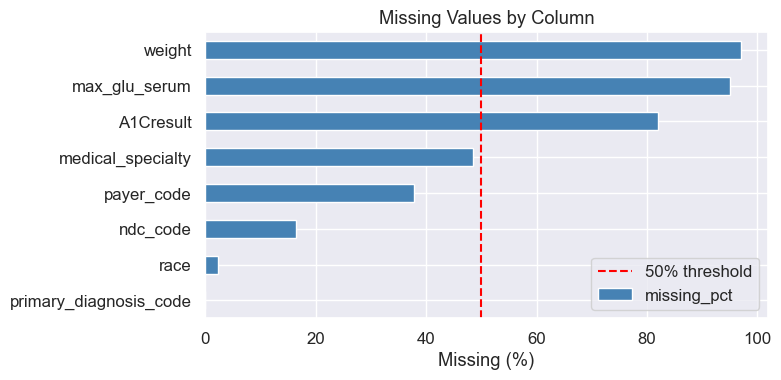

In [61]:
# Visualise missingness
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, max(4, len(missing_df) * 0.5)))
    missing_df['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    ax.axvline(50, color='red', linestyle='--', label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [62]:
# Drop columns with >40% missing; impute or recode the rest
HIGH_MISSING_THRESHOLD = 40
cols_to_drop = missing_df[missing_df.missing_pct > HIGH_MISSING_THRESHOLD].index.tolist()
print(f'Columns dropped (>{HIGH_MISSING_THRESHOLD}% missing): {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)

# 'weight' is typically ~97% missing — confirm and drop
if 'weight' in df.columns:
    print(f"'weight' missing: {df['weight'].isnull().mean()*100:.1f}% — dropping")
    df.drop(columns=['weight'], inplace=True, errors='ignore')

print(f'Shape after dropping high-missing columns: {df.shape}')

Columns dropped (>40% missing): ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']
Shape after dropping high-missing columns: (143424, 22)


In [63]:
# Recode 'race' missing values as 'Unknown'
if 'race' in df.columns:
    df['race'].fillna('Unknown', inplace=True)
    print("'race' NaNs filled with 'Unknown'")

# 'medical_specialty' — high missing; recode as 'Unknown'
if 'medical_specialty' in df.columns:
    df['medical_specialty'].fillna('Unknown', inplace=True)
    print("'medical_specialty' NaNs filled with 'Unknown'")

print(f'Remaining nulls: {df.isnull().sum().sum()}')

'race' NaNs filled with 'Unknown'
Remaining nulls: 77685


/var/folders/kk/1l55t5bn5cg93sx22k9gy5jm0000gp/T/ipykernel_3960/3323470922.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)


## 5. Data Cleaning

### 5.1 Remove Invalid / Irrelevant Records

In [64]:
# Drop ID columns — not predictive
id_cols = ['encounter_id', 'patient_nbr']
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)

# Remove deceased patients (discharge disposition 11, 19, 20, 21)
if 'discharge_disposition_id' in df.columns:
    deceased_codes = [11, 19, 20, 21]
    before = len(df)
    df = df[~df['discharge_disposition_id'].isin(deceased_codes)]
    print(f'Removed {before - len(df):,} deceased-patient records')

# Keep only one encounter per patient (the longest stay)
# — multiple encounters from the same patient introduce leakage

print(f'Shape after cleaning: {df.shape}')

Removed 1,923 deceased-patient records
Shape after cleaning: (141501, 20)


In [65]:
# Remove 'Unknown/Invalid' gender
if 'gender' in df.columns:
    before = len(df)
    df = df[df['gender'].isin(['Male', 'Female'])]
    print(f'Removed {before - len(df)} unknown-gender rows')
print(f'Final shape: {df.shape}')

Removed 5 unknown-gender rows
Final shape: (141496, 20)


### 5.2 Target Variable Encoding

The `readmitted` column has three values: `<30` (readmitted within 30 days), `>30`, and `NO`.  
We create a binary target: `1` = readmitted within 30 days, `0` = otherwise.

In [66]:
print('Original readmitted value counts:')
print(df['readmitted'].value_counts())

df['readmitted_30'] = (df['readmitted'] == '<30') * 1
print()
print('Binary target distribution:')
print(df['readmitted_30'].value_counts())
print(f'Positive rate: {df["readmitted_30"].mean()*100:.1f}%')

df.head(20)

Original readmitted value counts:
readmitted
NO     75320
>30    50434
<30    15742
Name: count, dtype: int64

Binary target distribution:
readmitted_30
0    125754
1     15742
Name: count, dtype: int64
Positive rate: 11.1%


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,primary_diagnosis_code,other_diagnosis_codes,...,number_inpatient,number_emergency,num_lab_procedures,number_diagnoses,num_medications,num_procedures,ndc_code,change,readmitted,readmitted_30
0,Caucasian,Female,[0-10),6,25,1,1,NaN,250.83,?|?,...,0,0,41,1,1,0,NaN,No,NO,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,276,250.01|255,...,0,0,59,9,18,0,68071-1701,Ch,>30,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,648,250|V27,...,1,0,11,6,13,5,0378-1110,No,NO,0
3,Caucasian,Male,[30-40),1,1,7,2,NaN,8,250.43|403,...,0,0,44,7,16,1,68071-1701,Ch,NO,0
4,Caucasian,Male,[40-50),1,1,7,1,NaN,197,157|250,...,0,0,51,5,8,0,0049-4110,Ch,NO,0
5,Caucasian,Male,[40-50),1,1,7,1,NaN,197,157|250,...,0,0,51,5,8,0,68071-1701,Ch,NO,0
6,Caucasian,Male,[50-60),2,1,2,3,NaN,414,411|250,...,0,0,31,9,16,6,47918-902,No,>30,0
7,Caucasian,Male,[60-70),3,1,2,4,NaN,414,411|V45,...,0,0,70,7,21,1,35208-001,Ch,NO,0
8,Caucasian,Male,[60-70),3,1,2,4,NaN,414,411|V45,...,0,0,70,7,21,1,16729-001,Ch,NO,0
9,Caucasian,Male,[60-70),3,1,2,4,NaN,414,411|V45,...,0,0,70,7,21,1,47918-891,Ch,NO,0


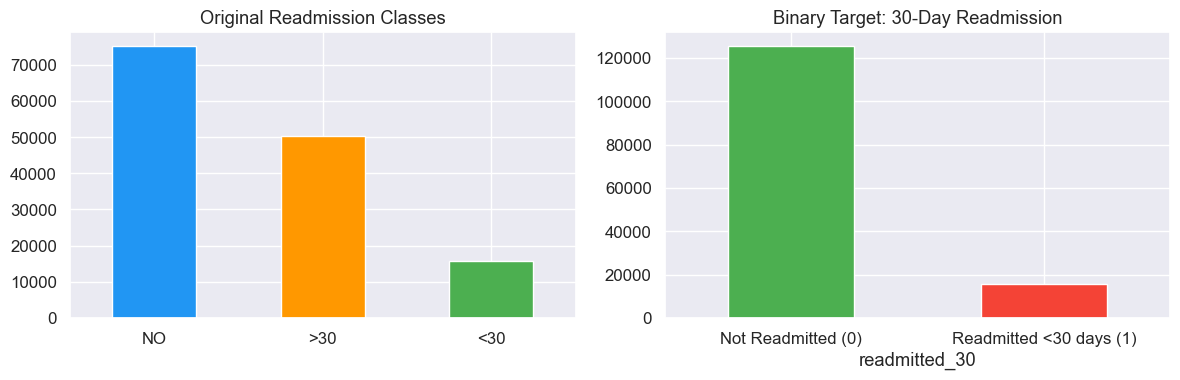

Class imbalance will need to be addressed in modelling.


In [67]:
# Visualise target balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original 3-class
df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white')
axes[0].set_title('Original Readmission Classes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Binary target
df['readmitted_30'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], edgecolor='white')
axes[1].set_title('Binary Target: 30-Day Readmission')
axes[1].set_xticklabels(['Not Readmitted (0)', 'Readmitted <30 days (1)'], rotation=0)

plt.tight_layout()
plt.show()
print('Class imbalance will need to be addressed in modelling.')

## 6. Exploratory Data Analysis

### 6.1 Demographic Features

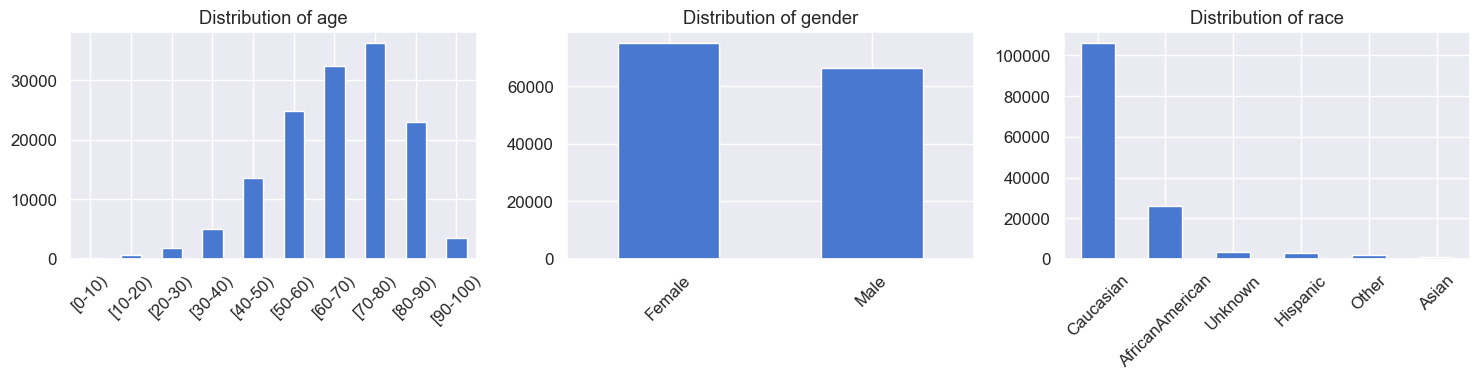

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['age', 'gender', 'race']):
    if col in df.columns:
        order = sorted(df[col].unique()) if col == 'age' else None
        vc = df[col].value_counts()
        if order:
            vc = vc.reindex(order).dropna()
        vc.plot(kind='bar', ax=ax, edgecolor='white')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


--- 30-Day Readmission Metrics by Age ---
              n readmit_pct
age                        
[0-10)      160       1.88%
[10-20)     732       5.60%
[20-30)    1919      13.44%
[30-40)    4954      10.80%
[40-50)   13651      10.34%
[50-60)   24924       9.40%
[60-70)   32388      10.98%
[70-80)   36337      11.72%
[80-90)   22956      12.71%
[90-100)   3475      12.12%

--- 30-Day Readmission Metrics by Gender ---
            n readmit_pct
gender                   
Female  75195      11.25%
Male    66301      10.99%

--- 30-Day Readmission Metrics by Race ---
                      n readmit_pct
race                               
Caucasian        106236      11.32%
AfricanAmerican   26052      11.02%
Unknown            3263       8.55%
Hispanic           2923       9.65%
Other              2146       9.46%
Asian               876       9.59%


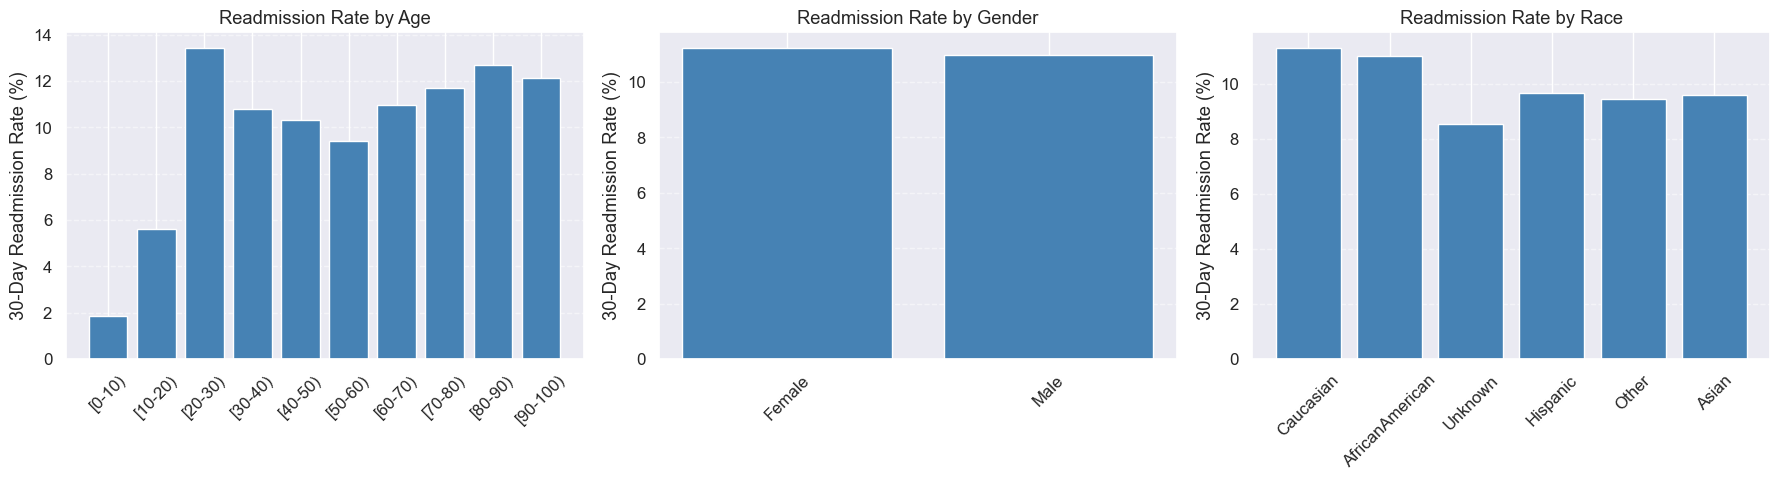

In [69]:
# Define the demographic target attributes
demographic_cols = ['age', 'gender', 'race']

# Construct a side-by-side 1x3 subplot visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, demographic_cols):
    if col in df.columns:
        # Aggregate data: Calculate readmission rate (mean) and volume (count)
        dem_stats = (df.groupby(col)['readmitted_30']
                       .agg(['mean', 'count'])
                       .rename(columns={'mean': 'readmit_rate', 'count': 'n'}))

        # Sort age chronologically if applicable; sort others descending by sample size
        if col == 'age':
            dem_stats = dem_stats.sort_index()
        else:
            dem_stats = dem_stats.sort_values(by='n', ascending=False)

        # Convert baseline probability to a percentage scalar
        dem_stats['readmit_pct'] = dem_stats['readmit_rate'] * 100

        # Generate professional bar chart using clinical corporate blue palette
        ax.bar(dem_stats.index, dem_stats['readmit_pct'], color='steelblue', edgecolor='white')
        ax.set_ylabel('30-Day Readmission Rate (%)')
        ax.set_title(f'Readmission Rate by {col.capitalize()}')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.5) # Structural background grid for precision

        # Output clean text tables to the terminal/console log
        print(f"\n--- 30-Day Readmission Metrics by {col.capitalize()} ---")
        print(dem_stats[['n', 'readmit_pct']].to_string(formatters={'readmit_pct': '{:.2f}%'.format}))

plt.tight_layout()
plt.show()

### 6.2 Utilisation Features

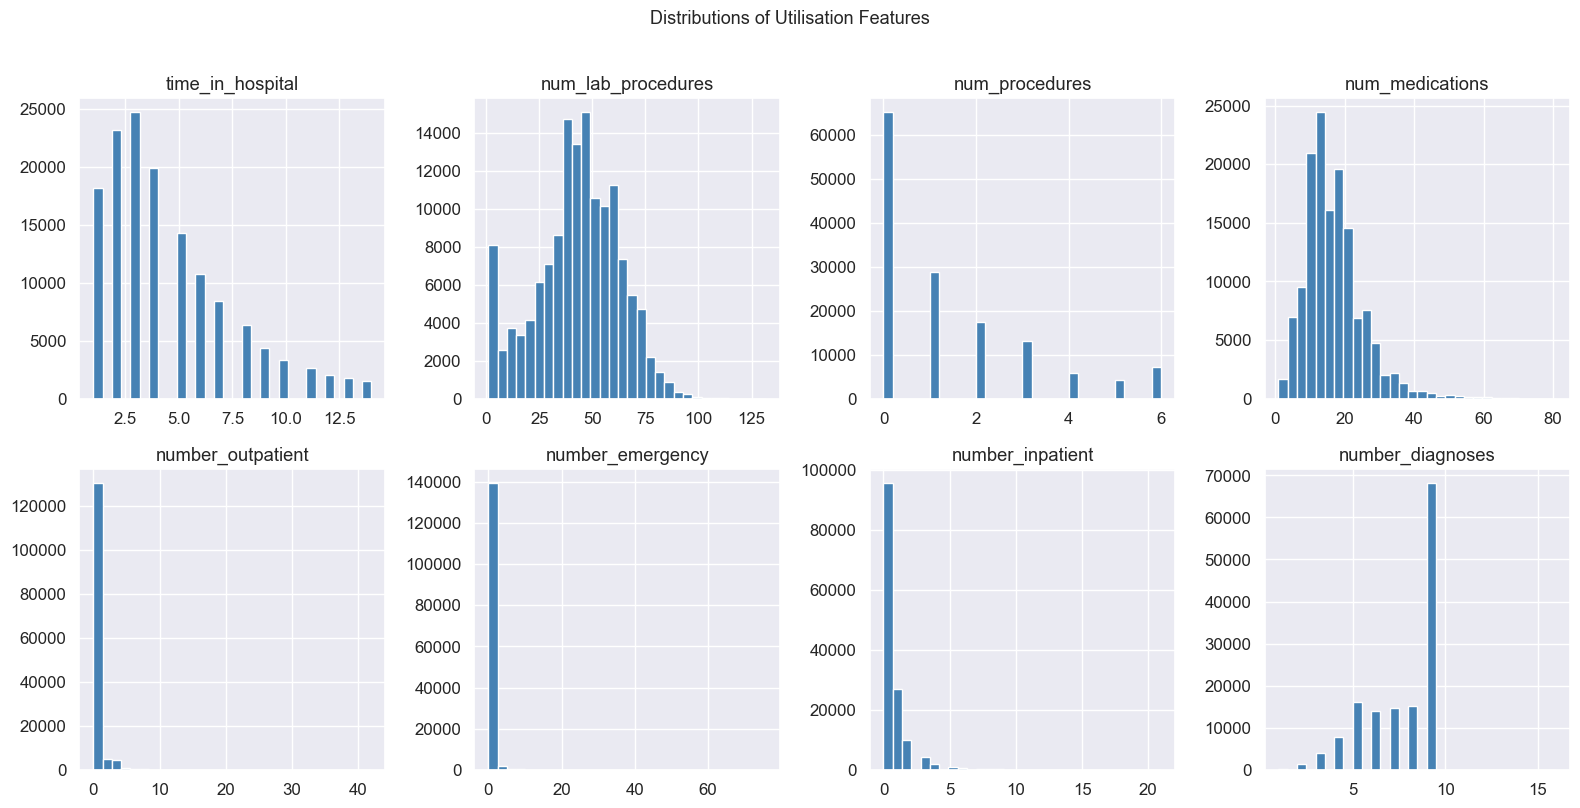

In [70]:
util_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
              'num_medications', 'number_outpatient', 'number_emergency',
              'number_inpatient', 'number_diagnoses']
util_cols = [c for c in util_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(util_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(util_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Utilisation Features', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

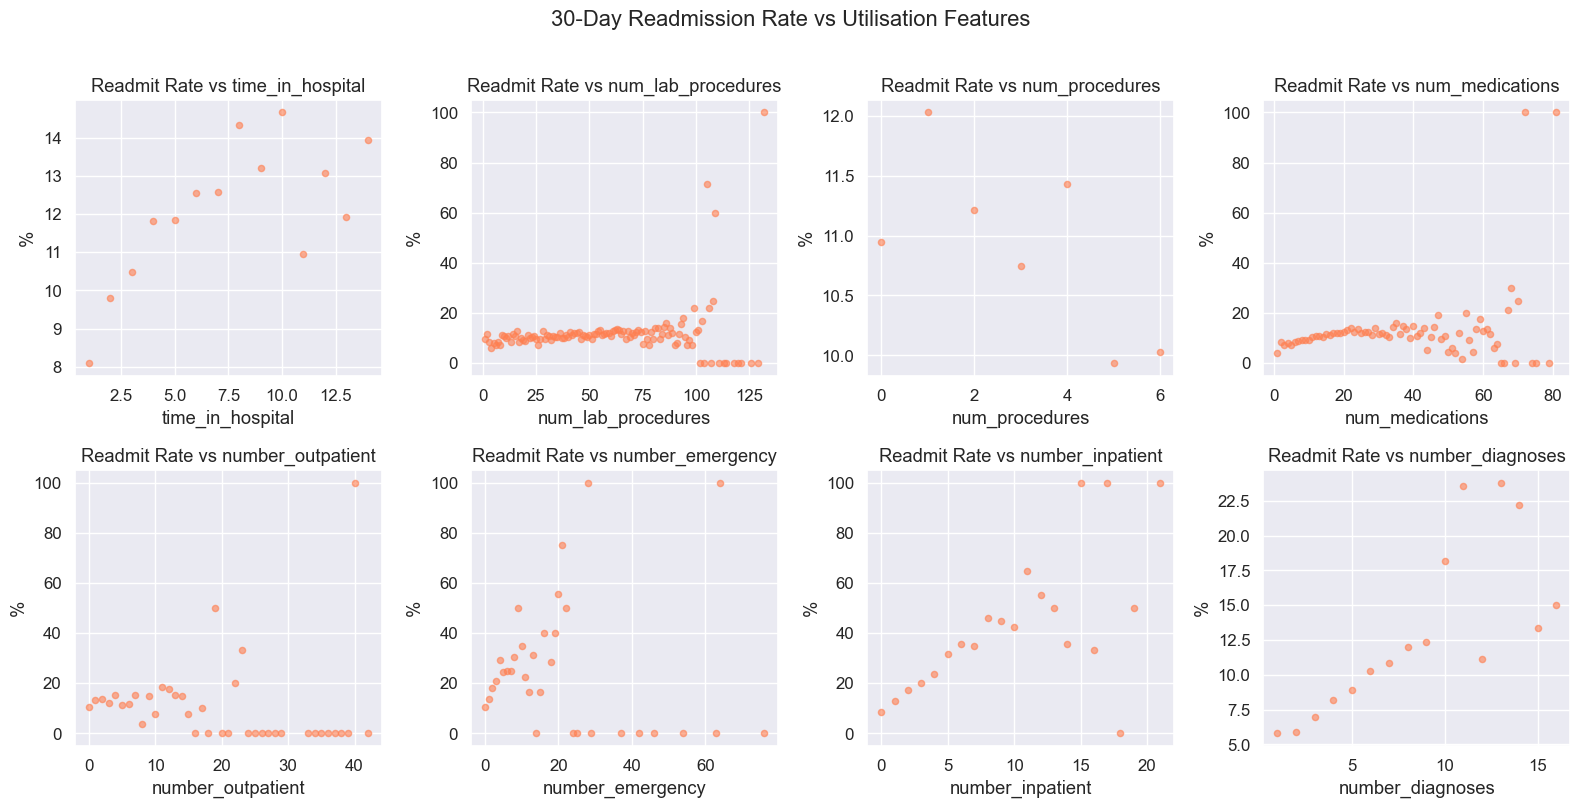

In [71]:
# Readmission rate vs utilisation features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(util_cols):
    rate = df.groupby(col)['readmitted_30'].mean() * 100
    axes[i].scatter(rate.index, rate.values, alpha=0.6, s=20, color='coral')
    axes[i].set_title(f'Readmit Rate vs {col}')
    axes[i].set_ylabel('%')
    axes[i].set_xlabel(col)

for j in range(len(util_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('30-Day Readmission Rate vs Utilisation Features', y=1.01)
plt.tight_layout()
plt.show()

### 6.3 HbA1c and Medication Features

HbA1c measurement and result are clinically important — prior research shows that  
patients who had HbA1c measured had lower readmission rates (Strack et al., 2014).

In [72]:
if 'A1Cresult' in df.columns:
    print('A1Cresult distribution:')
    print(df['A1Cresult'].value_counts())
    print()
    readmit_a1c = df.groupby('A1Cresult')['readmitted_30'].mean() * 100
    print('Readmission rate by A1Cresult:')
    print(readmit_a1c.round(2))

    fig, ax = plt.subplots(figsize=(7, 4))
    readmit_a1c.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_ylabel('30-Day Readmission Rate (%)')
    ax.set_title('Readmission Rate by HbA1c Result')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

In [73]:
# Diabetes medication change and readmission
if 'change' in df.columns:
    print('Medication change vs readmission:')
    print(df.groupby('change')['readmitted_30'].agg(['mean','count']).round(4))

if 'diabetesMed' in df.columns:
    print()
    print('Diabetes medication prescribed vs readmission:')
    print(df.groupby('diabetesMed')['readmitted_30'].agg(['mean','count']).round(4))

Medication change vs readmission:
          mean  count
change               
Ch      0.1132  87826
No      0.1080  53670


### 6.4 Correlation Heatmap (Numeric Features)

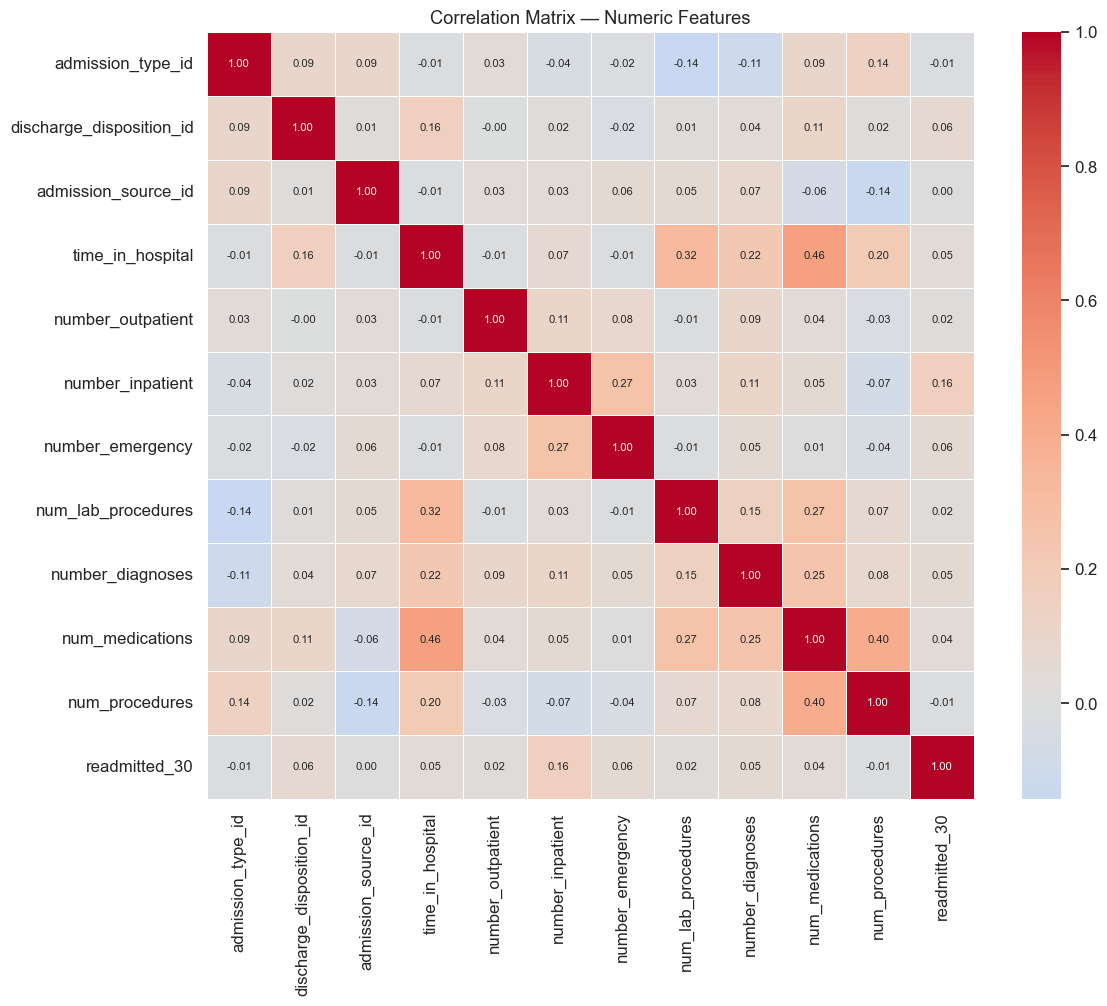

In [74]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'readmitted_30' in numeric_cols:
    numeric_cols.remove('readmitted_30')

corr_matrix = df[numeric_cols + ['readmitted_30']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [75]:
# Top correlations with target
target_corr = corr_matrix['readmitted_30'].drop('readmitted_30').sort_values(key=abs, ascending=False)
print('Top correlations with readmitted_30:')
print(target_corr.head(15).round(4))

Top correlations with readmitted_30:
number_inpatient            0.1583
discharge_disposition_id    0.0643
number_emergency            0.0592
number_diagnoses            0.0526
time_in_hospital            0.0452
num_medications             0.0364
num_lab_procedures          0.0229
number_outpatient           0.0160
admission_type_id          -0.0136
num_procedures             -0.0067
admission_source_id         0.0040
Name: readmitted_30, dtype: float64


### 6.5 Discharge Disposition

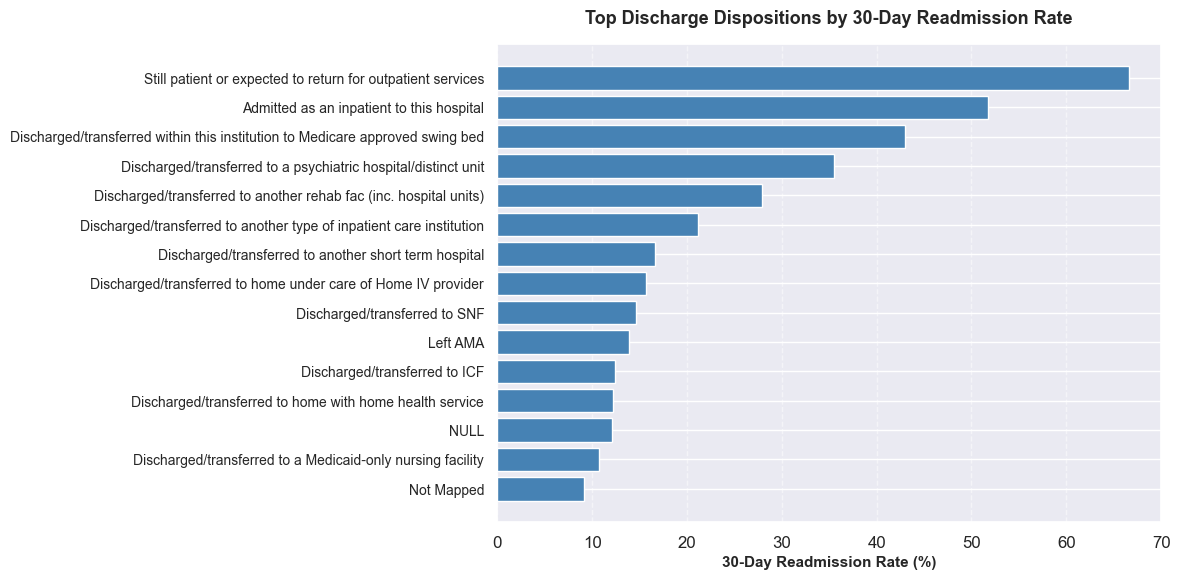


--- Top 15 Discharge Dispositions by Readmission Rate ---
                                                                                   n rate_pct
discharge_disposition_id                                                                     
Still patient or expected to return for outpatient services                        3   66.67%
Admitted as an inpatient to this hospital                                         29   51.72%
Discharged/transferred within this institution to Medicare approved swing bed     93   43.01%
Discharged/transferred to a psychiatric hospital/distinct unit                   200   35.50%
Discharged/transferred to another rehab fac (inc. hospital units)               3075   27.93%
Discharged/transferred to another type of inpatient care institution            1631   21.21%
Discharged/transferred to another short term hospital                           2906   16.66%
Discharged/transferred to home under care of Home IV provider                    147   15.65%
D

In [76]:
# 1. Hardcoded dictionary mapping based on IDS_mapping.csv
DISCHARGE_MAPPING = {
    1: 'Discharged to home',
    2: 'Discharged/transferred to another short term hospital',
    3: 'Discharged/transferred to SNF',
    4: 'Discharged/transferred to ICF',
    5: 'Discharged/transferred to another type of inpatient care institution',
    6: 'Discharged/transferred to home with home health service',
    7: 'Left AMA',
    8: 'Discharged/transferred to home under care of Home IV provider',
    9: 'Admitted as an inpatient to this hospital',
    10: 'Neonate discharged to another hospital for neonatal aftercare',
    11: 'Expired',
    12: 'Still patient or expected to return for outpatient services',
    13: 'Hospice / home',
    14: 'Hospice / medical facility',
    15: 'Discharged/transferred within this institution to Medicare approved swing bed',
    16: 'Discharged/transferred/referred another institution for outpatient services',
    17: 'Discharged/transferred/referred to this institution for outpatient services',
    18: 'NULL',
    19: 'Expired at home. Medicaid only, hospice.',
    20: 'Expired in a medical facility. Medicaid only, hospice.',
    21: 'Expired, place unknown. Medicaid only, hospice.',
    22: 'Discharged/transferred to another rehab fac (inc. hospital units)',
    23: 'Discharged/transferred to a long term care hospital.',
    24: 'Discharged/transferred to a Medicaid-only nursing facility',
    25: 'Not Mapped',
    26: 'Unknown/Invalid',
    27: 'Discharged/transferred to a federal health care facility.',
    28: 'Discharged/transferred to a psychiatric hospital/distinct unit',
    29: 'Discharged/transferred to a Critical Access Hospital (CAH).',
    30: 'Discharged/transferred to another Type of Health Care Institution'
}

# 2. Aggregation and Mapping Logic
if 'discharge_disposition_id' in df.columns:
    # Compute readmission volumes and rates
    disp_rate = (df.groupby('discharge_disposition_id')['readmitted_30']
                   .agg(['mean', 'count'])
                   .rename(columns={'mean': 'rate', 'count': 'n'})
                   .sort_values('rate', ascending=False)
                   .head(15))

    disp_rate['rate_pct'] = disp_rate['rate'] * 100

    # Map raw integer IDs to their corresponding hardcoded textual descriptions
    disp_rate.index = disp_rate.index.map(lambda x: DISCHARGE_MAPPING.get(int(x), f"ID {x}"))

    # For horizontal bar charts (barh), sorting ascending ensures the highest rate is at the top
    disp_rate_sorted = disp_rate.sort_values('rate_pct', ascending=True)

    # 3. Seminar-Professional Visualization Construction
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.barh(disp_rate_sorted.index, disp_rate_sorted['rate_pct'], color='steelblue', edgecolor='white')

    ax.set_xlabel('30-Day Readmission Rate (%)', fontsize=11, fontweight='bold')
    ax.set_title('Top Discharge Dispositions by 30-Day Readmission Rate', fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    # Adjust tick font sizes for long labels
    ax.tick_params(axis='y', labelsize=10)

    # Save the plot with tight bounds to prevent label clipping/truncation
    plt.tight_layout()
    plt.savefig('discharge_disposition_readmission.png', bbox_inches='tight', dpi=300)
    plt.show()

    print("\n--- Top 15 Discharge Dispositions by Readmission Rate ---")
    print(disp_rate[['n', 'rate_pct']].to_string(formatters={'rate_pct': '{:.2f}%'.format}))


## 7. Save Cleaned Dataset

In [77]:
import os
os.makedirs('data', exist_ok=True)

CLEAN_PATH = 'data/diabetic_clean.csv'
df.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved to {CLEAN_PATH}')
print(f'Final shape: {df.shape}')
print(f'Target positive rate: {df["readmitted_30"].mean()*100:.1f}%')

Cleaned dataset saved to data/diabetic_clean.csv
Final shape: (141496, 21)
Target positive rate: 11.1%


## 8. Key Analytical Takeaways & Modeling Rationale

* **Class Imbalance Management:** The ~11% base readmission rate confirms standard classification accuracy will be an uninformative metric. Downstream pipelines must mandate threshold-agnostic evaluation (ROC-AUC) combined with cost-sensitive boundary weighting (`class_weight='balanced'`) to mitigate severe negative-class bias.
* **Predictive Signal of Prior Utilization:** Historical encounter tracking - specifically inpatient (`number_inpatient`) and emergency (`number_emergency`) volume—serves as the primary baseline risk indicator, mathematically validating the presence of entrenched clinical high-utilization.
* **Clinical Assessment Gaps (HbA1c):** A substantial proportion of the cohort lacks verified HbA1c testing records. Tracking this data sparsity is vital; in alignment with domain literature (*Strack et al., 2014*), regular glycemic monitoring heavily correlates with stabilized readmission rates.
* **Operational Variation in Discharge Destinations:** Baseline probabilities are highly sensitive to post-acute placement. Higher-acuity discharge pathways, such as transfers to Skilled Nursing Facilities (SNF), exhibit elevated risk profiles that demand targeted categorical mapping and transitional care tracking.
* **Dimensionality of Pharmaceutical Regimens:** High-dimensional feature structures across ~24 distinct diabetic medication columns necessitate aggregate feature engineering (e.g., tracking the presence of an acute medication `change`) to capture therapeutic complexity without introducing excessive matrix sparsity.

---
**➡ Proceed to Notebook 2: Feature Engineering and Baseline Models**
